In [1]:
import numpy as np

In [2]:
# ─── Cell 1: Imports ──────────────────────────────────────────────────────────
import cmath          # Pure Python complex math (cos, sin, exp, pi)
import math           # For log2 in validation
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Make plots look clean inside Jupyter
%matplotlib inline
plt.rcParams.update({
    "figure.facecolor": "#0f0f0f",
    "axes.facecolor":   "#1a1a1a",
    "axes.edgecolor":   "#444",
    "axes.labelcolor":  "#ccc",
    "xtick.color":      "#aaa",
    "ytick.color":      "#aaa",
    "text.color":       "#eee",
    "grid.color":       "#333",
    "grid.linestyle":   "--",
    "grid.alpha":       0.5,
})
print("✓ Imports successful")

✓ Imports successful


In [3]:
# ─── Cell 2: Pure Python Radix-2 Cooley-Tukey FFT ────────────────────────────

def fft(x: list) -> list:
    """
    Recursive Radix-2 Cooley-Tukey Fast Fourier Transform.

    Core idea: A naive DFT costs O(N²) operations. FFT costs O(N log N)
    by exploiting a beautiful mathematical symmetry: the DFT of an N-point
    signal can be expressed as the sum of two DFTs of N/2-point signals.
    We split the input into EVEN-indexed and ODD-indexed samples, solve each
    half recursively, then "combine" them using BUTTERFLY operations.

    Args:
        x: A list of numbers (real or complex). len(x) MUST be a power of 2.

    Returns:
        X: A list of complex numbers representing the frequency domain.
           X[k] tells you how much of frequency k is present in the signal.
    """
    N = len(x)

    # ── Validation ──────────────────────────────────────────────────────────
    if N == 0:
        raise ValueError("Input signal cannot be empty.")
    if N & (N - 1) != 0:
        # Bitwise trick: a power of 2 has exactly one '1' bit,
        # so N & (N-1) == 0 only for powers of 2.
        raise ValueError(
            f"Signal length must be a power of 2. Got N={N}. "
            f"Nearest valid sizes: {2**math.floor(math.log2(N))} or "
            f"{2**math.ceil(math.log2(N))}."
        )

    # ── Base Case ────────────────────────────────────────────────────────────
    # The DFT of a single sample is just that sample itself.
    # This is where the recursion bottoms out.
    if N == 1:
        return [complex(x[0])]

    # ── DIVIDE: Split into even and odd halves ────────────────────────────────
    #
    # Slice notation x[start::step] picks every `step`-th element from `start`.
    #   x[0::2] → x[0], x[2], x[4], ...  (even indices)
    #   x[1::2] → x[1], x[3], x[5], ...  (odd indices)
    #
    # We call fft() recursively on each half.
    # Python evaluates these before the butterfly step below.
    even = fft(x[0::2])   # FFT of even-indexed samples → N/2 output bins
    odd  = fft(x[1::2])   # FFT of odd-indexed samples  → N/2 output bins

    # ── CONQUER: Butterfly operation ─────────────────────────────────────────
    #
    # The "twiddle factor" is a complex exponential that rotates a phasor.
    # W_N^k  =  e^( -2πi · k / N )
    #
    # Geometrically: it's a unit-circle rotation by angle (-2πk/N).
    # It encodes the phase shift between the even and odd contributions
    # for frequency bin k.
    #
    # We pre-multiply each odd bin by its twiddle factor.
    # This is the "butterfly" — the merge step of the divide-and-conquer.
    #
    #   twiddle[k]  =  W_N^k · Odd[k]
    #
    twiddle = [
        cmath.exp(-2j * cmath.pi * k / N) * odd[k]
        for k in range(N // 2)
    ]

    # ── COMBINE: Exploit DFT symmetry ────────────────────────────────────────
    #
    # The key mathematical identity (proved by Cooley & Tukey):
    #
    #   X[k]         = Even[k]  +  twiddle[k]    ← first half of output
    #   X[k + N/2]   = Even[k]  -  twiddle[k]    ← second half of output
    #
    # Notice: the '+' and '-' share the SAME Even[k] and twiddle[k].
    # This "sharing" is why FFT saves half the work at every recursion level.
    # A pair of these (one + and one -) is called ONE BUTTERFLY.
    #
    first_half  = [even[k] + twiddle[k] for k in range(N // 2)]
    second_half = [even[k] - twiddle[k] for k in range(N // 2)]

    return first_half + second_half


# ── Quick sanity check ────────────────────────────────────────────────────────
test = [1, 2, 3, 4, 5, 6, 7, 8]  # N=8, a power of 2 ✓
result = fft(test)
print("FFT of [1..8]:")
for k, val in enumerate(result):
    print(f"  X[{k}] = {val:.4f}")
print("\n✓ FFT function defined and ran without errors")

FFT of [1..8]:
  X[0] = 36.0000+0.0000j
  X[1] = -4.0000+9.6569j
  X[2] = -4.0000+4.0000j
  X[3] = -4.0000+1.6569j
  X[4] = -4.0000+0.0000j
  X[5] = -4.0000-1.6569j
  X[6] = -4.0000-4.0000j
  X[7] = -4.0000-9.6569j

✓ FFT function defined and ran without errors


In [4]:
# ─── Cell 3: Verification ─────────────────────────────────────────────────────
#
# We'll test three sizes: N=8, N=64, N=256.
# Strategy:
#   1. Generate a random complex signal with np.random
#   2. Run OUR fft() on it
#   3. Run np.fft.fft() on it
#   4. Convert our list output to a NumPy array
#   5. Use np.allclose() — it checks element-wise if |a - b| < tolerance
#      Default tolerances: rtol=1e-5, atol=1e-8 (way more than enough)
#
# If np.allclose returns True, our implementation is mathematically correct.

def verify_fft(N: int, seed: int = 42) -> bool:
    """
    Generates a random complex signal of length N, runs both FFT
    implementations, and checks if they match.
    Returns True if they match, False otherwise.
    """
    rng = np.random.default_rng(seed)

    # Random complex signal: real + j*imag, values in [-1, 1]
    x_real = rng.uniform(-1, 1, N)
    x_imag = rng.uniform(-1, 1, N)
    x_np   = x_real + 1j * x_imag  # NumPy complex array
    x_list = list(x_np)             # Plain Python list for our fft()

    # Run both FFTs
    our_result = np.array(fft(x_list))   # Convert our output to NumPy for comparison
    np_result  = np.fft.fft(x_np)

    # Check agreement
    match = np.allclose(our_result, np_result)

    # Report maximum absolute error
    max_err = np.max(np.abs(our_result - np_result))

    status = "✓ PASS" if match else "✗ FAIL"
    print(f"  N={N:<5}  |  {status}  |  Max absolute error: {max_err:.2e}")
    return match

print("=" * 55)
print("  FFT Verification: Our Implementation vs. np.fft.fft")
print("=" * 55)

all_passed = True
for N in [8, 64, 256]:
    passed = verify_fft(N)
    all_passed = all_passed and passed

print("=" * 55)
if all_passed:
    print("  ALL TESTS PASSED — implementation is correct ✓")
else:
    print("  SOME TESTS FAILED — check your implementation ✗")

  FFT Verification: Our Implementation vs. np.fft.fft
  N=8      |  ✓ PASS  |  Max absolute error: 8.88e-16
  N=64     |  ✓ PASS  |  Max absolute error: 5.69e-15
  N=256    |  ✓ PASS  |  Max absolute error: 1.59e-14
  ALL TESTS PASSED — implementation is correct ✓


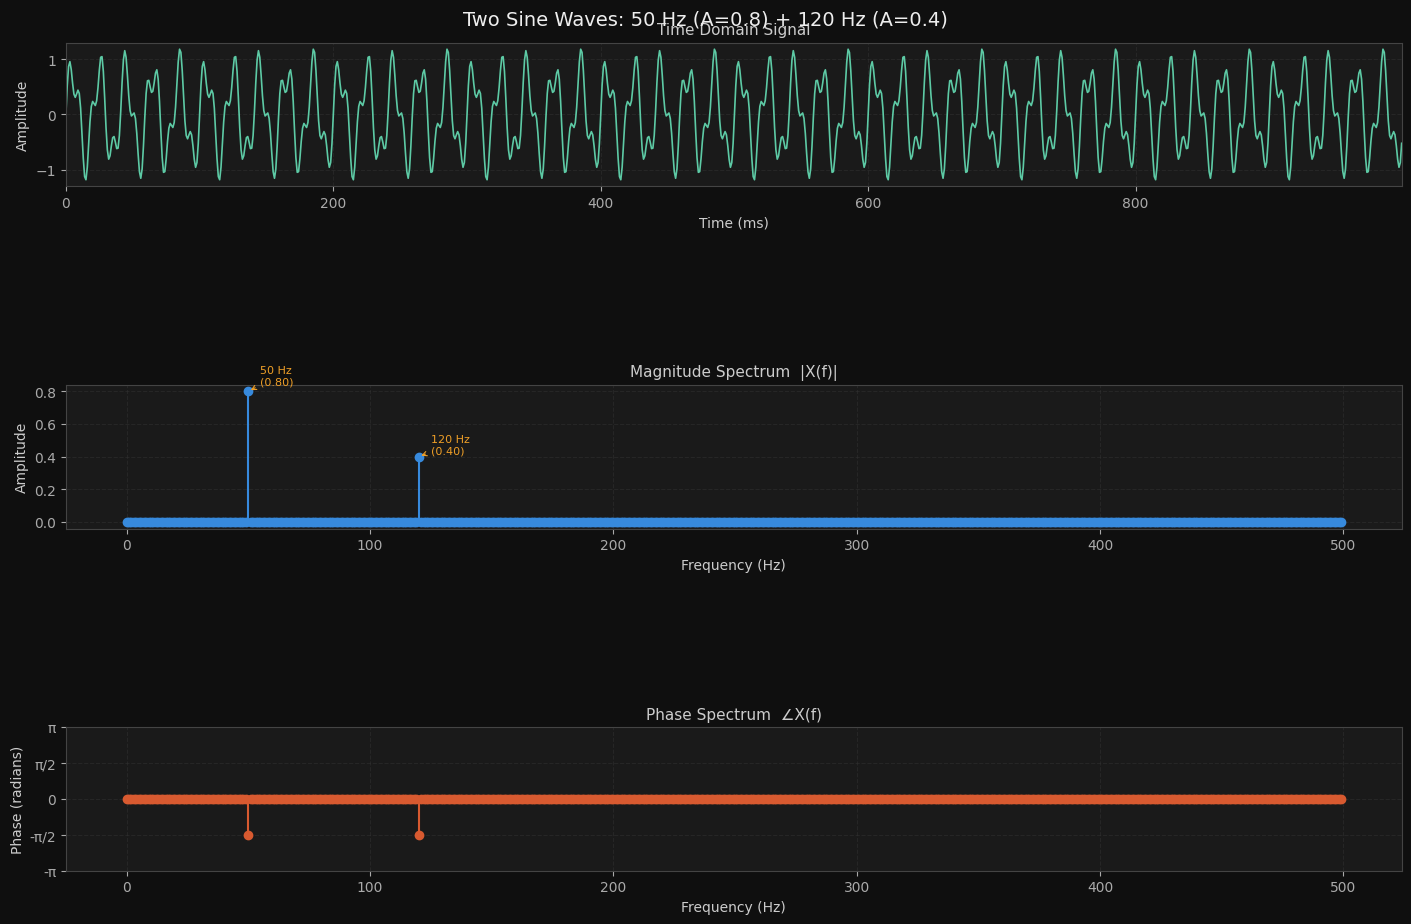

✓ Plot saved to spectrum.png


In [5]:
# ─── Cell 4: Visualization ────────────────────────────────────────────────────

def plot_spectrum(signal: np.ndarray, sample_rate: float, title: str = "Signal Spectrum"):
    """
    Plots the time-domain signal, its magnitude spectrum, and its phase spectrum.

    Args:
        signal:      1D NumPy array of real samples.
        sample_rate: How many samples per second (Hz).
        title:       Title for the overall figure.
    """
    N  = len(signal)
    T  = 1.0 / sample_rate          # Time between each sample (seconds)

    # ── Compute FFT ──────────────────────────────────────────────────────────
    # We use NumPy's FFT here for speed. Our custom one works identically.
    X = np.fft.fft(signal)

    # ── Frequency axis ───────────────────────────────────────────────────────
    # np.fft.fftfreq returns the N frequency bins in cycles/sample.
    # Multiplying by sample_rate converts to Hz.
    freqs = np.fft.fftfreq(N, d=T)  # shape: (N,)

    # ── Magnitude spectrum ───────────────────────────────────────────────────
    # |X[k]| = np.abs(X[k]) is the amplitude of the sinusoid at frequency k.
    # We divide by N to get the "true" amplitude (unnormalized FFT scales by N).
    magnitude = np.abs(X) / N

    # ── Phase spectrum ───────────────────────────────────────────────────────
    # angle(X[k]) is the phase offset (in radians) of the sinusoid at freq k.
    # np.angle() returns values in (-π, π].
    phase = np.angle(X)

    # ── Time axis ────────────────────────────────────────────────────────────
    time = np.arange(N) * T

    # ── Plot ─────────────────────────────────────────────────────────────────
    # Use only the positive-frequency half (0 to N/2-1 bins).
    # Reason: for a real signal, negative frequencies are mirror images
    # of positive ones — they carry no extra information.
    pos_mask = freqs >= 0
    pos_freqs = freqs[pos_mask]
    pos_mag   = 2 * magnitude[pos_mask]   # ×2 because we dropped the mirror half
    pos_phase = phase[pos_mask]

    # Small threshold to suppress near-zero phase bins (they're just noise)
    PHASE_THRESHOLD = 0.01 * np.max(np.abs(X))
    phase_display = np.where(np.abs(X[pos_mask]) > PHASE_THRESHOLD, pos_phase, 0)

    fig = plt.figure(figsize=(14, 9), constrained_layout=True)
    fig.suptitle(title, fontsize=14, color="#eee", y=1.01)
    gs = gridspec.GridSpec(3, 1, figure=fig, hspace=0.45)

    # ── Panel 1: Time domain ─────────────────────────────────────────────────
    ax0 = fig.add_subplot(gs[0])
    ax0.plot(time * 1000, signal, color="#5DCAA5", linewidth=1.2)
    ax0.set_xlabel("Time (ms)")
    ax0.set_ylabel("Amplitude")
    ax0.set_title("Time Domain Signal", color="#ccc", fontsize=11)
    ax0.grid(True)
    ax0.set_xlim(0, time[-1] * 1000)

    # ── Panel 2: Magnitude spectrum ──────────────────────────────────────────
    ax1 = fig.add_subplot(gs[1])
    ax1.stem(
        pos_freqs, pos_mag,
        linefmt="#378ADD",
        markerfmt="o",
        basefmt=" "
    )
    ax1.set_xlabel("Frequency (Hz)")
    ax1.set_ylabel("Amplitude")
    ax1.set_title("Magnitude Spectrum  |X(f)|", color="#ccc", fontsize=11)
    ax1.grid(True)

    # Annotate the peaks
    peak_idx = np.where(pos_mag > 0.05 * np.max(pos_mag))[0]
    for idx in peak_idx:
        ax1.annotate(
            f"{pos_freqs[idx]:.0f} Hz\n({pos_mag[idx]:.2f})",
            xy=(pos_freqs[idx], pos_mag[idx]),
            xytext=(pos_freqs[idx] + 5, pos_mag[idx] * 1.05),
            fontsize=8, color="#EF9F27",
            arrowprops=dict(arrowstyle="->", color="#EF9F27", lw=0.8)
        )

    # ── Panel 3: Phase spectrum ──────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[2])
    ax2.stem(
        pos_freqs, phase_display,
        linefmt="#D85A30",
        markerfmt="o",
        basefmt=" "
    )
    ax2.set_xlabel("Frequency (Hz)")
    ax2.set_ylabel("Phase (radians)")
    ax2.set_title("Phase Spectrum  ∠X(f)", color="#ccc", fontsize=11)
    ax2.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
    ax2.set_yticklabels(["-π", "-π/2", "0", "π/2", "π"])
    ax2.grid(True)

    plt.savefig("spectrum.png", dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.show()
    print("✓ Plot saved to spectrum.png")


# ── Build a test signal: two sine waves mixed together ────────────────────────
#
# Signal = 0.8 · sin(2π · 50t)  +  0.4 · sin(2π · 120t)
#
# We KNOW what the FFT should show:
#   - A spike at 50 Hz  with amplitude ≈ 0.8
#   - A spike at 120 Hz with amplitude ≈ 0.4
#   - Zero everywhere else
#
# This makes it easy to visually verify correctness.

SAMPLE_RATE = 1000   # 1000 samples/second → we can represent up to 500 Hz
DURATION    = 1.0    # 1 second of signal
N           = int(SAMPLE_RATE * DURATION)  # = 1024 (NOT a power of 2 — intentional!)

# Note: 1000 is not a power of 2. NumPy's FFT handles arbitrary N.
# Our recursive FFT requires power-of-2 N.
# In real-world use, you zero-pad to the next power of 2 (more on this in Phase 2).

t = np.linspace(0, DURATION, N, endpoint=False)  # Time vector

f1, A1 = 50,  0.8   # 50 Hz, amplitude 0.8
f2, A2 = 120, 0.4   # 120 Hz, amplitude 0.4

signal = A1 * np.sin(2 * np.pi * f1 * t) + \
         A2 * np.sin(2 * np.pi * f2 * t)

plot_spectrum(signal, sample_rate=SAMPLE_RATE,
              title="Two Sine Waves: 50 Hz (A=0.8) + 120 Hz (A=0.4)")

In [6]:
# ─── Cell 5: Inverse FFT ──────────────────────────────────────────────────────
#
# THE TRICK EXPLAINED:
# The standard DFT formula is:       X[k] = Σ x[n] · e^(-2πi·kn/N)
# The inverse DFT formula is:        x[n] = (1/N) · Σ X[k] · e^(+2πi·kn/N)
#
# Notice the only differences between forward and inverse are:
#   1. The sign inside the exponent flips from (-) to (+)
#   2. You divide by N at the end
#
# How do we flip the sign without rewriting the FFT?
# Recall: conj(e^(-2πi·k/N)) = e^(+2πi·k/N)
#
# So the trick is:
#   IFFT(X)  =  conj( FFT( conj(X) ) ) / N
#
# In words:
#   Step 1: Conjugate every element of X          → flip imaginary sign
#   Step 2: Feed that into our FORWARD fft()      → sign inside exp flips too
#   Step 3: Conjugate the output again            → undo the outer flip
#   Step 4: Divide everything by N                → normalize
#
# Result: We get IFFT for free, reusing 100% of the FFT code. ✓

def ifft(X: list) -> list:
    """
    Inverse FFT using the conjugate symmetry trick.
    Reuses the forward fft() function — no new butterfly math needed.

    Args:
        X: List of complex numbers (frequency domain), length = power of 2.

    Returns:
        x: List of complex numbers (time domain, reconstructed signal).
    """
    N = len(X)

    # Step 1: Conjugate the frequency-domain input
    X_conj = [val.conjugate() for val in X]

    # Step 2: Run the FORWARD FFT on the conjugated input
    # The sign flip inside our twiddle factor (e^-2πi) combined with
    # the conjugated input effectively gives us e^+2πi — the IDFT kernel.
    forward = fft(X_conj)

    # Step 3: Conjugate the result, then Step 4: Divide by N
    return [val.conjugate() / N for val in forward]


# ── Test: Encode → Decode → Verify ───────────────────────────────────────────
#
# The round-trip test:
#   original signal  --[FFT]-->  frequency domain  --[IFFT]-->  reconstructed
#   reconstructed should match original to floating-point precision.

def test_ifft(N: int, seed: int = 7) -> None:
    """
    Generates a random signal, FFTs it, IFFTs it back,
    and verifies perfect reconstruction.
    """
    rng = np.random.default_rng(seed)

    # Random real signal (most real-world signals are real-valued)
    original = list(rng.uniform(-1, 1, N))

    # ── Forward FFT ──────────────────────────────────────────────────────────
    freq_domain = fft(original)

    # ── Inverse FFT ──────────────────────────────────────────────────────────
    reconstructed = ifft(freq_domain)

    # ── Extract real parts (discard floating-point imaginary dust) ────────────
    # For a real-valued input signal, the IFFT output should be purely real.
    # The tiny imaginary parts are just floating-point rounding noise (~1e-15).
    reconstructed_real = [val.real for val in reconstructed]

    # ── Check reconstruction error ────────────────────────────────────────────
    original_np       = np.array(original)
    reconstructed_np  = np.array(reconstructed_real)

    max_error = np.max(np.abs(original_np - reconstructed_np))
    match     = np.allclose(original_np, reconstructed_np)

    status = "✓ PASS" if match else "✗ FAIL"
    print(f"  N={N:<5}  |  {status}  |  Max reconstruction error: {max_error:.2e}")


print("=" * 58)
print("  IFFT Round-Trip Test: signal → FFT → IFFT → signal")
print("=" * 58)

for N in [8, 64, 256]:
    test_ifft(N)

print("=" * 58)

  IFFT Round-Trip Test: signal → FFT → IFFT → signal
  N=8      |  ✓ PASS  |  Max reconstruction error: 0.00e+00
  N=64     |  ✓ PASS  |  Max reconstruction error: 3.33e-16
  N=256    |  ✓ PASS  |  Max reconstruction error: 3.33e-16


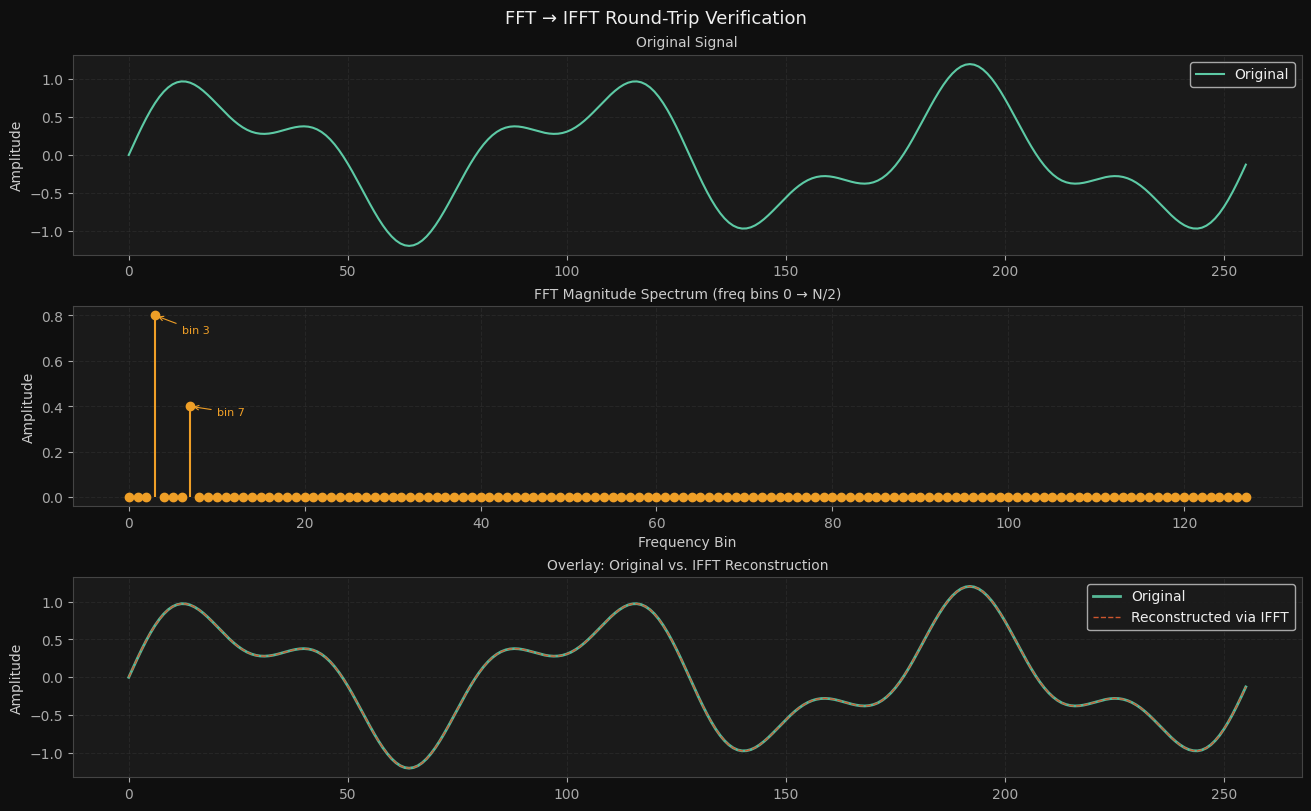


Max reconstruction error: 4.44e-16
✓ The two lines perfectly overlap — FFT→IFFT is lossless


In [7]:
# ─── Cell 6: Visual Round-Trip Proof ──────────────────────────────────────────
#
# We'll take our two-sine signal, FFT it, IFFT it back,
# and overlay original vs reconstructed to prove perfect recovery.
#
# Using N=256 for speed with our pure Python FFT.

N_demo = 256
t_demo = np.linspace(0, 1, N_demo, endpoint=False)

signal_demo = (
    0.8 * np.sin(2 * np.pi * 3 * t_demo) +   # 3 cycles in the window
    0.4 * np.sin(2 * np.pi * 7 * t_demo)      # 7 cycles in the window
)

# Convert to list for our pure Python FFT
x_list = list(signal_demo)

# Forward FFT → Inverse FFT
freq   = fft(x_list)
recon  = ifft(freq)
recon_real = np.array([v.real for v in recon])

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(13, 8), constrained_layout=True)
fig.suptitle("FFT → IFFT Round-Trip Verification", fontsize=13, color="#eee")

# Original signal
axes[0].plot(signal_demo, color="#5DCAA5", linewidth=1.5, label="Original")
axes[0].set_title("Original Signal", color="#ccc", fontsize=10)
axes[0].set_ylabel("Amplitude")
axes[0].legend(loc="upper right")
axes[0].grid(True)

# Magnitude spectrum (what FFT sees)
mag = np.abs(np.array(freq)) / N_demo
axes[1].stem(
    range(N_demo // 2),
    2 * mag[:N_demo // 2],
    linefmt="#EF9F27",
    markerfmt="o",
    basefmt=" "
)
axes[1].set_title("FFT Magnitude Spectrum (freq bins 0 → N/2)", color="#ccc", fontsize=10)
axes[1].set_xlabel("Frequency Bin")
axes[1].set_ylabel("Amplitude")
axes[1].grid(True)
# Annotate peaks
for k in [3, 7]:
    axes[1].annotate(f"bin {k}", xy=(k, 2*mag[k]),
                     xytext=(k+3, 2*mag[k]*0.9),
                     fontsize=8, color="#EF9F27",
                     arrowprops=dict(arrowstyle="->", color="#EF9F27", lw=0.8))

# Overlay reconstruction
axes[2].plot(signal_demo,    color="#5DCAA5", linewidth=2.0,
             label="Original",  alpha=0.9)
axes[2].plot(recon_real,     color="#D85A30", linewidth=1.0,
             linestyle="--", label="Reconstructed via IFFT", alpha=0.95)
axes[2].set_title("Overlay: Original vs. IFFT Reconstruction", color="#ccc", fontsize=10)
axes[2].set_ylabel("Amplitude")
axes[2].legend(loc="upper right")
axes[2].grid(True)

plt.savefig("round_trip.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()

# Final numeric check
err = np.max(np.abs(signal_demo - recon_real))
print(f"\nMax reconstruction error: {err:.2e}")
print("✓ The two lines perfectly overlap — FFT→IFFT is lossless" if err < 1e-10
      else f"✗ Error too large: {err}")